### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
    # use annotated , that save the list of message ai message nad humman message both
    # here we will append the message.

In [3]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_fa7f5b168b', 'id': 'chatcmpl-D3jgHnmG3QRPWFgoqq5Vvt5ImBDLQ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c0f48-c387-7022-8e3a-dd1e0139dc83-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [ ]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="qwen/qwen3-32b")
llm_groq.invoke("Hey I am rishabh and i like to play cricket")

AIMessage(content="<think>\nOkay, the user introduced themselves as Rishabh and mentioned they like playing cricket. I should respond in a friendly and engaging way. First, acknowledge their name and interest. Maybe ask them why they like cricket to get a conversation going. I could also mention some popular cricketers or teams to see if they have preferences. Let me make sure the response is open-ended so they feel comfortable sharing more. Keep the tone positive and enthusiastic. Avoid any assumptions about their skill level or specific aspects they enjoy. Maybe suggest discussing strategies, favorite players, or even tips for improving. Yeah, that should cover it. Let me put that together.\n</think>\n\nHey Rishabh! 🏏 That's awesome—cricket is such a thrilling game to play and watch. What do you love most about it? Is it the strategy, the batting, bowling, or maybe the team camaraderie? Do you have a favorite format (Test, ODI, T20) or any cricketers you look up to? I’d love to hear 

### We Will start With Creating Nodes

In [8]:
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

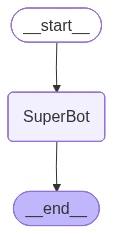

In [9]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile()


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [10]:
## Invocation

graph_builder.invoke({'messages':"Hi,My name is rishabh And I like cricket"})

{'messages': [HumanMessage(content='Hi,My name is rishabh And I like cricket', additional_kwargs={}, response_metadata={}, id='226ffb58-d59e-4c75-b1d6-25b142b3c266'),
  AIMessage(content="<think>\nOkay, the user mentioned they like cricket. I should respond in a friendly way and ask about the specific aspects they're interested in. I need to make sure to keep the conversation engaging and find out more about what they enjoy within the sport. Maybe ask about their favorite team or what they like most about playing or watching cricket. Also, offer help if they need more information. Keep the tone positive and open. I should avoid any jargon and keep the questions simple and relatable. Let me structure the response to encourage them to share more. Alright, let's put that together.\n</think>\n\nHi Rishabh! That's awesome—cricket is such a thrilling sport! 🏏 Whether you're into the fast-paced action of T20s, the strategic depth of Test matches, or just love the camaraderie of playing a frie

#### Streaming The responses

In [11]:
for event in graph_builder.stream({"messages":"Hello My name is rishabh"}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content='<think>\nOkay, so the user introduced themselves as Rishabh. Let me make sure I respond appropriately. First, I should acknowledge their greeting and name in a friendly way. Maybe say something like "Hello Rishabh!" to be welcoming.\n\nNow, I need to think about how to ask if they need help. A simple "How can I assist you today?" works well. It\'s open-ended and shows I\'m here to help with whatever they need. \n\nI should keep the tone positive and approachable. Maybe add an emoji to make it feel more personable, like a smiley face 😊. Let me check the response again: "Hello Rishabh! 😊 How can I assist you today?" That sounds good. It\'s friendly, acknowledges their name, and invites them to ask for help. I don\'t see any issues with this response. It should encourage them to share what they need next.\n</think>\n\nHello Rishabh! 😊 How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20